# Ruta B: Ciencia de Datos

## ICD Financiero S.A. | Optimización de la Gestión de Quejas

**Objetivo:** Identificar combinaciones de entidad, producto y motivo que concentran mayor riesgo
regulatorio, y construir un modelo que anticipe ese riesgo.

**Dataset:** 1.044.110 registros trimestrales | 2014–2026 | Superintendencia Financiera de Colombia


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder


import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Configuración global de visualización
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder


import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Sección 0: Setup y Carga


In [2]:
DATA_PATH = Path('Challenge_DataAI_Candidatos.csv')

df = pd.read_csv(
    DATA_PATH,
    sep=';',
    encoding='latin-1',
    dtype={'CODIGO_ENTIDAD': str}
)

# Strip de espacios en nombres de columna
df.columns = df.columns.str.strip()

# Verificación inmediata de carga
print(f"Shape: {df.shape}")
print(f"\nTipos de dato:\n{df.dtypes}")
print(f"\nPrimeras filas:")
df.head(3)

/tmp/ipykernel_44605/3100169084.py:3: DtypeWarning: Columns (0: TIPO_ENTIDAD) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Shape: (1044109, 18)

Tipos de dato:
TIPO_ENTIDAD                            object
CODIGO_ENTIDAD                             str
NOMBRE_ENTIDAD                             str
FECHA_CORTE                                str
UNIDAD_CAPTURA                         float64
NOMBRE_UNIDAD_CAPTURA                      str
CODIGO_PRODUCTO                        float64
PRODUCTO                                   str
CODIGO_MOTIVO                          float64
MOTIVO                                     str
QUEJAS_PENDIENTES                      float64
QUEJAS_RECIBIDAS                       float64
QUEJAS_FINALIZADAS                     float64
QUEJAS_FINALIZADAS_N1                  float64
QUEJAS_FINALIZADAS_N2                  float64
QUEJAS_EN_TRAMITE                      float64
QUEJAS_FAVOR_CONSUM_ACEP_ENT           float64
QUEJAS_FAVOR_CONSUM_NOACEP_ENT,,,,,        str
dtype: object

Primeras filas:


,TIPO_ENTIDAD,CODIGO_ENTIDAD,NOMBRE_ENTIDAD,FECHA_CORTE,UNIDAD_CAPTURA,NOMBRE_UNIDAD_CAPTURA,CODIGO_PRODUCTO,PRODUCTO,CODIGO_MOTIVO,MOTIVO,QUEJAS_PENDIENTES,QUEJAS_RECIBIDAS,QUEJAS_FINALIZADAS,QUEJAS_FINALIZADAS_N1,QUEJAS_FINALIZADAS_N2,QUEJAS_EN_TRAMITE,QUEJAS_FAVOR_CONSUM_ACEP_ENT,"QUEJAS_FAVOR_CONSUM_NOACEP_ENT,,,,,"
0,14,11,Banco SevoraMERICANA S.A.,30/06/2023,2.00,DEFENSORES DEL CONSUMIDOR FINANCIERO,28.00,SEGURO DE SALUD,135.00,INCUMPLIMIENTO DE OBLIGACIONES EN PRESTACI??N ...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"0,,,,,"
1,14,11,Banco SevoraMERICANA S.A.,31/03/2024,1.00,ENTIDAD VIGILADA,36.00,SEGURO DE RENTAS VOLUNTARIAS,20.00,"DEMORA O NO DEVOLUCI??N DE SALDOS, APORTES O P...",0.00,0.00,0.00,0.00,0.00,0.00,0.00,"0,,,,"
2,13,18,Banco OximiaMERICANA S.A.,30/09/2024,2.00,DEFENSORES DEL CONSUMIDOR FINANCIERO,7.00,SEGURO DE SUSTRACCI??N,13.00,DEMORA O NO ENTREGA DEL CONTRATO O DE LA P??LIZA,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"0,,,,,"


In [3]:
df.columns = df.columns.str.strip().str.rstrip(',') #QUEJAS_FAVOR_CONSUM_NOACEP_ENT sin ','

In [4]:
df['QUEJAS_FAVOR_CONSUM_NOACEP_ENT'] = (
    df['QUEJAS_FAVOR_CONSUM_NOACEP_ENT']
    .str.rstrip(',')
    .str.strip()
    .replace('', np.nan)
    .astype(float)
)

In [5]:
df.isnull().sum(axis=1).value_counts().sort_index(ascending=False).head(3) #Filas nulas

17         16
0     1044093
Name: count, dtype: int64

### Constantes del proyecto:


In [6]:
# Columnas agrupadas por rol analítico
COLS_ID        = ['TIPO_ENTIDAD', 'CODIGO_ENTIDAD', 'NOMBRE_ENTIDAD']
COLS_TIEMPO    = ['FECHA_CORTE']
COLS_PRODUCTO  = ['CODIGO_PRODUCTO', 'PRODUCTO']
COLS_MOTIVO    = ['CODIGO_MOTIVO', 'MOTIVO']
COLS_CANAL     = ['UNIDAD_CAPTURA', 'NOMBRE_UNIDAD_CAPTURA']
COLS_QUEJAS = [
    'QUEJAS_PENDIENTES', 'QUEJAS_RECIBIDAS', 'QUEJAS_FINALIZADAS',
    'QUEJAS_FINALIZADAS_N1', 'QUEJAS_FINALIZADAS_N2',
    'QUEJAS_EN_TRAMITE', 'QUEJAS_FAVOR_CONSUM_ACEP_ENT',
    'QUEJAS_FAVOR_CONSUM_NOACEP_ENT'
]

# Thresholds documentados en el enunciado
OUTLIER_EN_TRAMITE = 5_000

# Ventana de análisis de riesgo
ANIO_INICIO_RIESGO = 2021

In [7]:
# ¿N1 + N2 == FINALIZADAS?
check1 = ((df['QUEJAS_FINALIZADAS_N1'] + df['QUEJAS_FINALIZADAS_N2']).round(0) == df['QUEJAS_FINALIZADAS'].round(0)).mean()

# ¿ACEP + NOACEP == alguna de las columnas de finalizadas?
check2 = ((df['QUEJAS_FAVOR_CONSUM_ACEP_ENT'] + df['QUEJAS_FAVOR_CONSUM_NOACEP_ENT']).round(0) == df['QUEJAS_FINALIZADAS'].round(0)).mean()
check3 = ((df['QUEJAS_FAVOR_CONSUM_ACEP_ENT'] + df['QUEJAS_FAVOR_CONSUM_NOACEP_ENT']).round(0) == df['QUEJAS_FINALIZADAS_N2'].round(0)).mean()

print(f"N1 + N2 == FINALIZADAS: {check1:.2%}")
print(f"ACEP + NOACEP == FINALIZADAS: {check2:.2%}")
print(f"ACEP + NOACEP == N2: {check3:.2%}")

N1 + N2 == FINALIZADAS: 98.12%
ACEP + NOACEP == FINALIZADAS: 75.60%
ACEP + NOACEP == N2: 78.18%


## Hallazgos de Carga: Sección 0

| Hallazgo                                         | Detalle                                                                                      | Acción                                                                              |
| ------------------------------------------------ | -------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------- |
| Trailing commas en nombre de columna             | `QUEJAS_FAVOR_CONSUM_NOACEP_ENT,,,,,`                                                        | `str.rstrip(',')` en carga                                                          |
| Trailing commas en valores                       | `QUEJAS_FAVOR_CONSUM_NOACEP_ENT` tenía valores `'0,,,,,'` cargada como string                | Limpieza y conversión a float en carga                                              |
| 16 filas completamente nulas                     | Nulos uniformes en todas las columnas                                                        | Eliminación en S1                                                                   |
| N1 y N2 son nivel de atención                    | N1 = primera línea, N2 = segunda línea (escaladas). N1+N2 = FINALIZADAS en 98.12%            | Columnas se conservan con nombre original                                           |
| ACEP + NOACEP no reconstruye FINALIZADAS         | Coincidencia solo del 75.60% estas columnas representan un subconjunto, no el total          | Investigar en S2 (EDA)                                                              |
| Columnas de resolución favor consumidor ausentes | El enunciado describe `QUEJAS_FINALIZAD_FAVOR_CONSUM` y `FAVOR_ENTIDAD` no existen en el CSV | Variable objetivo se construirá desde `ACEP` y `NOACEP` decisión a justificar en S3 |


## Sección 1: Limpieza minima estructural


In [8]:
df_raw_shape = df.shape

Las 17 filas identificadas en S0 tienen 17/18 columnas nulas: el parser interpretó toda la fila como un string en `TIPO_ENTIDAD` por comillas dobles en el nombre de entidad. Se eliminan antes de cualquier análisis.


In [9]:
df.isnull().sum(axis=1).value_counts().sort_index(ascending=False)

17         16
0     1044093
Name: count, dtype: int64

In [10]:
mask_mal_parseadas = df.isnull().sum(axis=1) == 17
df = df[~mask_mal_parseadas].copy()

print(f"Filas eliminadas: {mask_mal_parseadas.sum()} | Shape final: {df.shape}")

Filas eliminadas: 16 | Shape final: (1044093, 18)


In [11]:
df['FECHA_CORTE'] = pd.to_datetime(df['FECHA_CORTE'], dayfirst=True, errors='coerce')
df['ANIO'] = df['FECHA_CORTE'].dt.year
df['TRIMESTRE'] = df['FECHA_CORTE'].dt.to_period('Q')

print(f"Fechas no parseadas: {df['FECHA_CORTE'].isna().sum()}")
print(df['ANIO'].value_counts().sort_index())

Fechas no parseadas: 0
ANIO
2014      9868
2015     14298
2016     15621
2017     16608
2018     16366
2019      9987
2020     16067
2021     16086
2022     14437
2023    225700
2024    303466
2025    308128
2026     77461
Name: count, dtype: int64


Salto en de 14437 a 225700 en un año.


Normalización de strings:


In [12]:
df['NOMBRE_ENTIDAD'] = df['NOMBRE_ENTIDAD'].str.strip().str.upper()
df['PRODUCTO']       = df['PRODUCTO'].str.strip()
df['MOTIVO']         = df['MOTIVO'].str.strip()

---


In [13]:
# ¿Los duplicados incluyen FECHA_CORTE o son idénticos en todo incluyendo fecha?
cols_key = ['CODIGO_ENTIDAD', 'FECHA_CORTE', 'CODIGO_PRODUCTO', 'CODIGO_MOTIVO', 'UNIDAD_CAPTURA']
n_dupes_key = df.duplicated(subset=cols_key).sum()
print(f"Duplicados en clave natural: {n_dupes_key}")
print(f"Duplicados exactos (todas columnas): {df.duplicated().sum()}")

Duplicados en clave natural: 715305
Duplicados exactos (todas columnas): 609514


In [14]:
# Ver un ejemplo concreto de duplicado exacto
clave = ['CODIGO_ENTIDAD', 'FECHA_CORTE', 'CODIGO_PRODUCTO', 'CODIGO_MOTIVO', 'UNIDAD_CAPTURA']
ejemplo = df[df.duplicated(subset=clave, keep=False)].sort_values(clave).head(10)
print(ejemplo[clave + ['QUEJAS_RECIBIDAS', 'QUEJAS_FINALIZADAS']].to_string())

        CODIGO_ENTIDAD FECHA_CORTE  CODIGO_PRODUCTO  CODIGO_MOTIVO  UNIDAD_CAPTURA  QUEJAS_RECIBIDAS  QUEJAS_FINALIZADAS
431554           00001  2023-09-30             1.00         122.00            1.00              1.00                1.00
490907           00001  2023-09-30             1.00         122.00            1.00              2.00                2.00
364990           00001  2024-06-30             1.00         134.00            1.00              1.00                1.00
370842           00001  2024-06-30             1.00         134.00            1.00              1.00                1.00
1001930          00001  2024-06-30             1.00         134.00            1.00             13.00               12.00
129958           00001  2024-12-31             1.00          20.00            1.00              3.00                3.00
184646           00001  2024-12-31             1.00          20.00            1.00              4.00                5.00
684095           00001  2024-12-

In [15]:
# ¿Cuántas combinaciones clave tienen más de un registro?
clave = ['CODIGO_ENTIDAD', 'FECHA_CORTE', 'CODIGO_PRODUCTO', 'CODIGO_MOTIVO', 'UNIDAD_CAPTURA']
conteo = df.groupby(clave).size()
print(conteo.value_counts().sort_index())

1      276789
2       16311
3        2588
4        1214
5         778
        ...  
192         1
196         1
220         1
222         1
499         1
Name: count, Length: 145, dtype: int64


In [16]:
# ¿Los múltiples registros por clave vienen de distintas UNIDAD_CAPTURA o de la misma?
clave_sin_canal = ['CODIGO_ENTIDAD', 'FECHA_CORTE', 'CODIGO_PRODUCTO', 'CODIGO_MOTIVO']
df_multi = df.groupby(clave_sin_canal).filter(lambda x: len(x) > 1)
print(df_multi.groupby(clave_sin_canal)['UNIDAD_CAPTURA'].nunique().value_counts())

UNIDAD_CAPTURA
2    73117
1    17290
Name: count, dtype: int64


In [17]:
# Los 609.514 duplicados exactos sí se eliminan — filas idénticas en todas las columnas.
# Las combinaciones con múltiples registros y valores distintos NO se tocan:
# 73.117 corresponden a doble reporte por fuente (entidad vs defensor) — diseño del dataset.
# 17.290 son doble reporte de la misma fuente — se documentan como limitación en S2.

n_before = len(df)
df = df.drop_duplicates()
print(f"Duplicados exactos eliminados: {n_before - len(df)} | Shape final: {df.shape}")

Duplicados exactos eliminados: 609514 | Shape final: (434579, 20)


In [18]:
print(f"Shape final S1: {df.shape}")
print(f"\nNulidad residual:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nDtipos:")
print(df.dtypes)

Shape final S1: (434579, 20)

Nulidad residual:
Series([], dtype: int64)

Dtipos:
TIPO_ENTIDAD                              object
CODIGO_ENTIDAD                               str
NOMBRE_ENTIDAD                               str
FECHA_CORTE                       datetime64[us]
UNIDAD_CAPTURA                           float64
NOMBRE_UNIDAD_CAPTURA                        str
CODIGO_PRODUCTO                          float64
PRODUCTO                                     str
CODIGO_MOTIVO                            float64
MOTIVO                                       str
QUEJAS_PENDIENTES                        float64
QUEJAS_RECIBIDAS                         float64
QUEJAS_FINALIZADAS                       float64
QUEJAS_FINALIZADAS_N1                    float64
QUEJAS_FINALIZADAS_N2                    float64
QUEJAS_EN_TRAMITE                        float64
QUEJAS_FAVOR_CONSUM_ACEP_ENT             float64
QUEJAS_FAVOR_CONSUM_NOACEP_ENT           float64
ANIO                                

In [19]:
print(f"Filas:    {df_raw_shape[0]:>10,}  →  {df.shape[0]:>10,}  ({df_raw_shape[0] - df.shape[0]:,} eliminadas)")
print(f"Columnas: {df_raw_shape[1]:>10}  →  {df.shape[1]:>10}  (+ANIO, +TRIMESTRE)")

Filas:     1,044,109  →     434,579  (609,530 eliminadas)
Columnas:         18  →          20  (+ANIO, +TRIMESTRE)


Se eliminaron filas mal parseadas, duplicados exactos y se unificaron fechas y strings. El dataset pasa de 1.044.110 a 434.579 fila.


## S2: Análisis Exploratorio de Datos

El EDA está organizado en cinco bloques que siguen una lógica acumulativa:
primero establecemos cuándo el dato cambia de naturaleza (Bloque 1),
luego dónde se concentra el volumen (Bloque 2), quién pierde las disputas
(Bloque 3), quién no resuelve (Bloque 4), y qué revela el canal externo
sobre la calidad de resolución interna (Bloque 5).


### Bloque 1: ¿cuándo cambia la naturaleza del dato?

Antes de cualquier análisis de tendencia, hay que establecer si el dataset
es comparable a lo largo del tiempo. Este bloque responde una sola pregunta:
¿el aumento de registros post-2023 refleja más quejas reales o un cambio
en cómo se reportan?


**¿Cuántos registros hay por año y cuándo ocurre el salto?**


In [20]:
#Registros por año
registros_anio = df.groupby('ANIO').size().reset_index(name='registros')
print(registros_anio.to_string(index=False))

 ANIO  registros
 2014       9860
 2015      14282
 2016      15606
 2017      16595
 2018      16353
 2019       9983
 2020      16049
 2021      16073
 2022      14425
 2023      79549
 2024      99532
 2025     100982
 2026      25290


**Lo que se ve:** Entre 2014 y 2022 el volumen oscila entre 10k y 16k registros anuales con relativa estabilidad, salvo una caída en 2019. En 2023 ocurre un salto de 14.425 a 79.549 que se consolida en 100k para 2024–2025.

**Lo que significa para el negocio:** Este salto no refleja un aumento real de quejas refleja un cambio en la granularidad del reporte. Cualquier comparación de volumen entre el periodo pre-2023 y post-2023 es inválida sin ajuste.


**¿Cuántas entidades únicas reportan por año?**


In [21]:
# Entidades únicas por año
entidades_anio = df.groupby('ANIO')['CODIGO_ENTIDAD'].nunique().reset_index(name='entidades_unicas')
print(entidades_anio.to_string(index=False))

 ANIO  entidades_unicas
 2014               107
 2015               114
 2016               121
 2017               120
 2018               120
 2019                68
 2020               127
 2021               123
 2022               123
 2023               141
 2024               136
 2025               133
 2026               116


**Lo que se ve:** El número de entidades únicas se mantiene estable entre 107 y 127 durante 2014-2022, con una caída anómala a 68 en 2019. En 2023 sube modestamente a 141 y luego se estabiliza en alrededor de 130.

**Lo que significa para el negocio:** El salto en registros de 2023 no vino de incorporar masivamente nuevas entidades el universo supervisado creció apenas un 15%. Eso confirma que el cambio fue de granularidad interna del reporte, no de cobertura.


**¿Aumentaron las combinaciones únicas producto \* motivo en 2023?**


In [22]:
# Combinaciones únicas producto * motivo por año
combos_anio = (df.groupby('ANIO')
               .apply(lambda x: x[['CODIGO_PRODUCTO', 'CODIGO_MOTIVO']].drop_duplicates().shape[0])
               .reset_index(name='combos_producto_motivo'))
print(combos_anio.to_string(index=False))

 ANIO  combos_producto_motivo
 2014                     520
 2015                     559
 2016                     571
 2017                     601
 2018                     603
 2019                     289
 2020                     602
 2021                     601
 2022                     606
 2023                    2408
 2024                    2440
 2025                    2447
 2026                    2300


**Lo que se ve:** Las combinaciones únicas producto \* motivo se mantienen entre 520 y 606 durante 2014–2022. En 2023 saltan a 2.408 y se estabilizan ahí en 2024–2025.

**Lo que significa para el negocio:** La hipótesis de cambio de granularidad queda confirmada. Antes de 2023 la Superfinanciera recibía reportes agregados a nivel producto, desde 2023 exige el desglose por motivo. Es más resolución del dato.


### Conclusión Bloque 1

Entre 2014 y 2022 el dataset registra entre 10k y 16k filas anuales con
aproximadamente 120 entidades reportando. En 2023 los registros saltan de 14.425
a 79.549 sin que el universo de entidades crezca proporcionalmente.

La causa es un cambio de granularidad: las combinaciones únicas
producto \* motivo aumentan de 600 a 2.400 en 2023, confirmando que
la Superfinanciera pasó de recibir reportes agregados por producto a
exigir el desglose por motivo.

**Implicación metodológica:** todo análisis de tendencia en este notebook
se ejecuta sobre dos periodos separados: 2014–2022 y 2023–2026.
No son comparables en volumen de registros.


### Bloque 2: Distribución y concentración de quejas

El volumen de quejas no está distribuido uniformemente entre entidades
ni productos. Este bloque responde: ¿qué tan concentrado está el riesgo
y quiénes son los actores que se deberían mirar primero?


**¿Cómo se distribuye QUEJAS_RECIBIDAS y qué tan sesgada es?**


In [23]:
#Distribución de QUEJAS_RECIBIDAS
import numpy as np

print(df['QUEJAS_RECIBIDAS'].describe(percentiles=[.25, .5, .75, .90, .95, .99]))
print(f"\nRegistros con QUEJAS_RECIBIDAS == 0: {(df['QUEJAS_RECIBIDAS'] == 0).sum():,}")
print(f"Registros con QUEJAS_RECIBIDAS > 100: {(df['QUEJAS_RECIBIDAS'] > 100).sum():,}")
print(f"Registros con QUEJAS_RECIBIDAS > 1000: {(df['QUEJAS_RECIBIDAS'] > 1000).sum():,}")

count   434579.00
mean        28.25
std        292.02
min          0.00
25%          0.00
50%          1.00
75%          3.00
90%         21.00
95%         68.00
99%        512.00
max      50413.00
Name: QUEJAS_RECIBIDAS, dtype: float64

Registros con QUEJAS_RECIBIDAS == 0: 196,547
Registros con QUEJAS_RECIBIDAS > 100: 16,718
Registros con QUEJAS_RECIBIDAS > 1000: 2,126


**Lo que se ve:** La mediana es 1 queja y el P75 es 3, pero la media es 28 y el máximo es 50.413. El 45% de los registros tiene cero quejas, y solo el 0.5% supera 1.000. La desviación estándar (292) es 10x la mediana.

**Lo que significa para el negocio:** La mayoría de combinaciones entidad-producto-motivo son ruido estadístico. El riesgo regulatorio real está concentrado en un puñado de registros de alto volumen. Usar la media como métrica de referencia en cualquier reporte supervisorio sería engañoso.


**¿Cuántas entidades concentran el 80% del volumen total de quejas?**


In [24]:
# Concentración por entidad
total_por_entidad = (df.groupby('CODIGO_ENTIDAD')['QUEJAS_RECIBIDAS']
                     .sum().sort_values(ascending=False))

cum_pct = total_por_entidad.cumsum() / total_por_entidad.sum() * 100

n_80 = (cum_pct < 80).sum() + 1
n_total = total_por_entidad.shape[0]

print(f"Total entidades: {n_total}")
print(f"Entidades que concentran el 80% del volumen: {n_80}")
print(f"Proporción: {n_80/n_total*100:.1f}% de las entidades")
print(f"\nTop 15 entidades por volumen:")
top15 = (df.groupby('NOMBRE_ENTIDAD')['QUEJAS_RECIBIDAS']
         .sum().sort_values(ascending=False).head(15))
print(top15.to_string())

Total entidades: 182
Entidades que concentran el 80% del volumen: 15
Proporción: 8.2% de las entidades

Top 15 entidades por volumen:
NOMBRE_ENTIDAD
BANCO UNI?N COLOMBIANA   1866147.00
BANCO AXENTRA            1269641.00
BANCO PRIMEBANK          1225776.00
CENTRIA BANK              665513.00
BANCO NOVACRED            473743.00
BANCO NEXCAPITAL          465068.00
BANCO CAPITALONEA         416405.00
REINVENT BANK             403780.00
BRAVIA FINANCIAL          374391.00
BANCO RESOLUTA            366803.00
MONETIA                   362908.00
BANCO ARISTA              360656.00
BANCO FORENTIA            306271.00
BANCO DEXTRA              305583.00
OCCIDENTA BANK            176169.00


**¿Cuáles son los productos con mayor volumen de quejas?**


In [25]:
# Concentración por producto
top_prod = (df.groupby('PRODUCTO')['QUEJAS_RECIBIDAS']
            .sum().sort_values(ascending=False).head(10))

total = df['QUEJAS_RECIBIDAS'].sum()
top_prod_pct = (top_prod / total * 100).round(1)

print("Top 10 productos por volumen de quejas:")
print(pd.DataFrame({'quejas': top_prod, 'pct_total': top_prod_pct}).to_string())

Top 10 productos por volumen de quejas:
                                      quejas  pct_total
PRODUCTO                                               
TARJETAS DE CR??DITO              4514126.00      36.80
CUENTA DE AHORROS                 2478950.00      20.20
CR??DITO DE CONSUMO Y/O COMERCIAL 1521346.00      12.40
CUENTA CORRIENTE                   595668.00       4.90
PENSI??N DE VEJEZ                  555275.00       4.50
CR??DITO DE VIVIENDA               378493.00       3.10
SEGURO DE AUTOM??VILES             299239.00       2.40
SEGURO DE VIDA GRUPO               205636.00       1.70
OTROS SEGUROS                      175240.00       1.40
SEGURO DE VIDA INDIVIDUAL          145095.00       1.20


**Lo que se ve:** Tarjetas de crédito concentran el 36.8% del total de quejas, más que los siguientes tres productos combinados. Cuenta de ahorros (20.2%) y crédito de consumo (12.4%) completan un top 3 que representa el 69.4% del volumen total. Los productos de seguros aparecen en la cola con menos del 2.5% cada uno.

**Lo que significa para el negocio:** El riesgo regulatorio por volumen está en productos masivos de uso cotidiano, no en productos complejos o de nicho. Una entidad con alta tasa de quejas en tarjetas de crédito tiene exposición regulatoria inmediata porque ese producto toca al mayor número de consumidores.


### Bloque 3: Tasa de resolución a favor del consumidor

Volumen alto no implica riesgo regulatorio alto. Este bloque responde:
¿quién está perdiendo las disputas con el consumidor y con qué frecuencia?
La métrica central es TASA_FAVOR, qué proporción de quejas resueltas
terminan a favor del consumidor.


In [26]:
# Diagnóstico del proxy
df['TOTAL_FAVOR'] = df['QUEJAS_FAVOR_CONSUM_ACEP_ENT'] + df['QUEJAS_FAVOR_CONSUM_NOACEP_ENT']

total = len(df)
con_finalizadas = (df['QUEJAS_FINALIZADAS'] > 0).sum()
con_favor = (df['TOTAL_FAVOR'] > 0).sum()
ambos = ((df['QUEJAS_FINALIZADAS'] > 0) & (df['TOTAL_FAVOR'] > 0)).sum()

print(f"Total registros:                     {total:,}")
print(f"Con QUEJAS_FINALIZADAS > 0:          {con_finalizadas:,} ({con_finalizadas/total*100:.1f}%)")
print(f"Con TOTAL_FAVOR > 0:                 {con_favor:,} ({con_favor/total*100:.1f}%)")
print(f"Con ambos > 0 (proxy calculable):    {ambos:,} ({ambos/total*100:.1f}%)")

# Casos imposibles: TOTAL_FAVOR > QUEJAS_FINALIZADAS
mask = (df['QUEJAS_FINALIZADAS'] > 0) & (df['TOTAL_FAVOR'] > 0)
df_v = df[mask].copy()
df_v['TASA_FAVOR'] = df_v['TOTAL_FAVOR'] / df_v['QUEJAS_FINALIZADAS']
imposibles = (df_v['TASA_FAVOR'] > 1).sum()
print(f"Casos con TASA_FAVOR > 1 (imposible): {imposibles:,} ({imposibles/len(df_v)*100:.1f}%)")

Total registros:                     434,579
Con QUEJAS_FINALIZADAS > 0:          240,216 (55.3%)
Con TOTAL_FAVOR > 0:                 109,718 (25.2%)
Con ambos > 0 (proxy calculable):    109,718 (25.2%)
Casos con TASA_FAVOR > 1 (imposible): 0 (0.0%)


**Lo que se ve:** El proxy solo es calculable en el 25.2% de los registros (109.718 de 434.579). No hay casos imposibles (TASA_FAVOR > 1), lo cual es buena noticia para la validez del proxy donde existe. El problema es de cobertura: el 74.8% de los registros no tiene información de resolución a favor del consumidor.

**Lo que significa para el negocio:** Tres cuartas partes del dataset no permiten evaluar la calidad de resolución.


**¿Cómo se distribuye TASA_FAVOR y dónde está el umbral natural de riesgo?**


In [27]:
#Distribución de TASA_FAVOR
print(df_v['TASA_FAVOR'].describe(percentiles=[.10, .25, .50, .75, .90]))

p75 = df_v['TASA_FAVOR'].quantile(0.75)
alto_riesgo = (df_v['TASA_FAVOR'] > p75).sum()
print(f"\nP75 (umbral ALTO_RIESGO): {p75:.3f}")
print(f"Registros sobre P75:      {alto_riesgo:,} ({alto_riesgo/len(df_v)*100:.1f}%)")
print(f"Registros con TASA_FAVOR > 0.70: {(df_v['TASA_FAVOR'] > 0.70).sum():,}")
print(f"Registros con TASA_FAVOR < 0.30: {(df_v['TASA_FAVOR'] < 0.30).sum():,}")

count   109718.00
mean         0.59
std          0.31
min          0.00
10%          0.17
25%          0.33
50%          0.54
75%          0.96
90%          1.00
max          1.00
Name: TASA_FAVOR, dtype: float64

P75 (umbral ALTO_RIESGO): 0.957
Registros sobre P75:      27,413 (25.0%)
Registros con TASA_FAVOR > 0.70: 40,855
Registros con TASA_FAVOR < 0.30: 23,785


**Lo que se ve:** La mediana de TASA_FAVOR es 0.54 y la media 0.59, más de la mitad de las quejas resueltas terminan a favor del consumidor. El P75 es 0.96 y el P90 llega a 1.0, lo que indica que una proporción importante de registros tiene tasas extremadamente altas. El umbral del enunciado (0.70) captura 40.855 registros; por debajo de 0.30 hay 23.785.

**Lo que significa para el negocio:** El P75 de 0.96 es una señal de alerta. Significa que en el cuartil superior las entidades están perdiendo prácticamente todas las disputas. Usar 0.70 como umbral de alto riesgo es razonable y está respaldado por la distribución real: captura el 37% de los registros con dato disponible.


**¿Qué entidades tienen TASA_FAVOR más alta con volumen significativo?**


In [28]:
#Entidades con mayor riesgo regulatorio
riesgo_ent = df_v.groupby('NOMBRE_ENTIDAD').agg(
    registros=('TASA_FAVOR', 'count'),
    quejas_finalizadas=('QUEJAS_FINALIZADAS', 'sum'),
    tasa_favor_media=('TASA_FAVOR', 'mean'),
).reset_index()

# Filtro: mínimo P25 de registros para evitar entidades marginales
p25_registros = riesgo_ent['registros'].quantile(0.25)
top_riesgo = (riesgo_ent[riesgo_ent['registros'] >= p25_registros]
              .sort_values('tasa_favor_media', ascending=False)
              .head(15))

print(f"Filtro mínimo registros (P25): {p25_registros:.0f}")
print(top_riesgo[['NOMBRE_ENTIDAD', 'registros', 'quejas_finalizadas', 'tasa_favor_media']].to_string(index=False))

Filtro mínimo registros (P25): 24
  NOMBRE_ENTIDAD  registros  quejas_finalizadas  tasa_favor_media
  BANCO TREVANTS         31               31.00              1.00
   BANCO CONEXIA         40              201.00              0.95
    BANCO ELIXOR         39               59.00              0.94
BANCO VANGUARDIA        114              155.00              0.93
      AURIA BANK         33               45.00              0.93
     BANCO REXTA         26               61.00              0.91
   BANCO ASCENTA         27               53.00              0.91
    BRINTAL BANK         49              118.00              0.91
    BANCO SENVIA         35               68.00              0.91
 BANCO CRECIENTE         76              126.00              0.89
  BANCO DIN?MICO        109              182.00              0.88
   BANCO OPERNIA         41              482.00              0.88
   BANCO MOVARIA         78              166.00              0.88
  BANCO MERIDIAN         51              5

**Lo que se ve:** Las 15 entidades con mayor TASA_FAVOR tienen tasas entre 0.86 y 1.00. Sin embargo, todas tienen volúmenes bajos: el máximo es 114 registros y 555 quejas finalizadas. Ninguna de las entidades del top 15 por volumen (Bloque 2) aparece aquí.

**Lo que significa para el negocio:** Hay dos tipos de riesgo regulatorio distintos. Riesgo por tasa: Entidades pequeñas que pierden casi todas las disputas. Y riesgo por volumen: Entidades grandes con miles de quejas. El supervisor necesita ambas listas, no solo una. Una entidad con TASA_FAVOR de 0.90 y 50 quejas es menos urgente que una con TASA_FAVOR de 0.65 y 500.000 quejas.


**¿Qué entidades combinan volumen alto con TASA_FAVOR alta — el riesgo compuesto?**


In [29]:
# Riesgo compuesto volumen * tasa
riesgo_compuesto = df_v.groupby('NOMBRE_ENTIDAD').agg(
    quejas_finalizadas=('QUEJAS_FINALIZADAS', 'sum'),
    tasa_favor_media=('TASA_FAVOR', 'mean'),
).reset_index()

# Normalizar ambas dimensiones y crear score compuesto
riesgo_compuesto['score'] = (
    (riesgo_compuesto['quejas_finalizadas'] / riesgo_compuesto['quejas_finalizadas'].max()) * 0.5 +
    riesgo_compuesto['tasa_favor_media'] * 0.5
)

top_compuesto = riesgo_compuesto.sort_values('score', ascending=False).head(15)
print(top_compuesto[['NOMBRE_ENTIDAD', 'quejas_finalizadas', 'tasa_favor_media', 'score']].to_string(index=False))

                                                      NOMBRE_ENTIDAD  quejas_finalizadas  tasa_favor_media  score
                                              BANCO UNI?N COLOMBIANA          1881136.00              0.55   0.78
                                                     BANCO PRIMEBANK          1221856.00              0.66   0.66
                                                       BANCO AXENTRA          1263285.00              0.57   0.62
                                                 BANCO UNITARIA PLUS              335.00              1.00   0.50
                                                      BANCO TREVANTS               31.00              1.00   0.50
          FINTESSA BANK SECURITIES SERVICES SOCIEDAD FIDUCIARIA S.A.               27.00              1.00   0.50
                                                     VENTUREX BANKCO               18.00              1.00   0.50
                QUANTARIS BANKORA DE CR?DITO Y DEL COMERCIO EXTERIOR               16.00

**Lo que se ve:** Banco Unión Colombiana lidera con score 0.78 dominando por volumen (1.88M quejas finalizadas) aunque su tasa es 0.55. Banco Primebank (score 0.66) y Banco Axentra (0.62) los top 3. Del puesto 4 en adelante, el score colapsa a 0.50 porque son entidades con tasa 1.00 pero volúmenes mínimos (4 a 335 quejas).

**Lo que significa para el negocio:** El score compuesto con pesos iguales (0.5/0.5) no discrimina bien en los extremos. Las tres entidades realmente críticas son Banco Unión Colombiana, Banco Primebank y Banco Axentra las mismas del top 3 por volumen, pero ahora con la dimensión de calidad de resolución añadida.


### Conclusión Bloque 3

La tasa de resolución a favor del consumidor (TASA_FAVOR) solo es
calculable en el 25.2% de los registros lo que implica una limitación estructural del
dataset que acota todas las conclusiones de este bloque al subconjunto
con dato disponible.

Donde el dato existe, la distribución es preocupante: la mediana es
0.54 y el P75 llega a 0.96, lo que significa que en el cuartil superior
las entidades pierden prácticamente todas sus disputas. El umbral de
alto riesgo (TASA_FAVOR > 0.70) captura 40.855 registros.

El riesgo regulatorio tiene dos caras:

- **Riesgo por tasa:** entidades pequeñas con tasas cercanas a 1.00. Pierden todo, pero su volumen es marginal.
- **Riesgo por volumen \* tasa:** Banco Unión Colombiana, Banco Primebank
  y Banco Axentra concentran el mayor riesgo compuesto. Son las mismas
  entidades que lideran el volumen, pero con tasas de resolución
  que confirman un problema sistémico de atención al consumidor.

**Implicación para la gestión:** una entidad con tasa alta y volumen
alto enfrenta exposición regulatoria inmediata ante la Superfinanciera.
Reducir la tasa requiere intervenir el proceso de resolución, no solo
el volumen de quejas recibidas.


### Bloque 4: Backlog y acumulación de riesgo

Una queja recibida que no se resuelve es deuda regulatoria acumulada.
Este bloque responde: ¿qué entidades reciben sistemáticamente más
quejas de las que resuelven, y qué tan crítico es su backlog?


**¿Cuál es el backlog neto por entidad?**


In [30]:
# Backlog neto por entidad
df['QUEJAS_NETAS'] = df['QUEJAS_RECIBIDAS'] - df['QUEJAS_FINALIZADAS']

backlog = df.groupby('NOMBRE_ENTIDAD').agg(
    quejas_recibidas=('QUEJAS_RECIBIDAS', 'sum'),
    quejas_finalizadas=('QUEJAS_FINALIZADAS', 'sum'),
    quejas_netas=('QUEJAS_NETAS', 'sum'),
).reset_index()

backlog['ratio_resolucion'] = backlog['quejas_finalizadas'] / backlog['quejas_recibidas'].replace(0, np.nan)

# Entidades con mayor backlog acumulado
top_backlog = backlog.sort_values('quejas_netas', ascending=False).head(15)
print(top_backlog[['NOMBRE_ENTIDAD', 'quejas_recibidas', 'quejas_finalizadas',
                   'quejas_netas', 'ratio_resolucion']].to_string(index=False))

            NOMBRE_ENTIDAD  quejas_recibidas  quejas_finalizadas  quejas_netas  ratio_resolucion
              CENTRIA BANK         665513.00           655850.00       9663.00              0.99
                 BANCAMIGA          63370.00            58325.00       5045.00              0.92
                   MONETIA         362908.00           358383.00       4525.00              0.99
             BANCO ALDORIA         146877.00           143657.00       3220.00              0.98
             BANCO DATIVIA          11848.00             9418.00       2430.00              0.79
               NOVACAPITAL          43546.00            41645.00       1901.00              0.96
              BANCO VALTUS          91938.00            90379.00       1559.00              0.98
             BANCO DATAVIA          53886.00            52392.00       1494.00              0.97
             REINVENT BANK         403780.00           402876.00        904.00              1.00
            BANCO NOVACRED    

**Lo que se ve:** Centria Bank lidera el backlog con 9.663 quejas netas acumuladas, seguido de Bancamiga (5.045) y Monetia (4.525). Sin embargo, los ratios de resolución son altos: entre 0.79 y 1.00 lo que indica que estas entidades resuelven la gran mayoría de lo que reciben. El backlog no viene de ineficiencia severa sino de volumen absoluto alto.

**Lo que significa para el negocio:** Un backlog de 9.663 quejas con ratio de resolución de 0.99 no es una crisis operativa es una entidad grande con flujo constante. El riesgo real está en Banco Dativia (ratio 0.79): resuelve solo 8 de cada 10 quejas que recibe, lo que genera acumulación estructural independientemente del volumen.


**¿Hay entidades con ratio QUEJAS_EN_TRAMITE / QUEJAS_RECIBIDAS > 1?**


In [31]:
#*Ratio en trámite
tramite = df.groupby('NOMBRE_ENTIDAD').agg(
    quejas_recibidas=('QUEJAS_RECIBIDAS', 'sum'),
    en_tramite=('QUEJAS_EN_TRAMITE', 'sum'),
).reset_index()

tramite['ratio_tramite'] = tramite['en_tramite'] / tramite['quejas_recibidas'].replace(0, np.nan)

# Entidades con ratio > 1 (más en trámite que recibidas — señal de alerta)
alerta = tramite[tramite['ratio_tramite'] > 1].sort_values('ratio_tramite', ascending=False)
print(f"Entidades con ratio EN_TRAMITE/RECIBIDAS > 1: {len(alerta)}")
print(alerta[['NOMBRE_ENTIDAD', 'quejas_recibidas', 'en_tramite', 'ratio_tramite']].to_string(index=False))

# Outliers absolutos en QUEJAS_EN_TRAMITE
outliers = df[df['QUEJAS_EN_TRAMITE'] > OUTLIER_EN_TRAMITE]
print(f"\nRegistros con QUEJAS_EN_TRAMITE > {OUTLIER_EN_TRAMITE}: {len(outliers)}")
print(outliers[['NOMBRE_ENTIDAD', 'FECHA_CORTE', 'QUEJAS_EN_TRAMITE']].to_string(index=False))

Entidades con ratio EN_TRAMITE/RECIBIDAS > 1: 8
  NOMBRE_ENTIDAD  quejas_recibidas  en_tramite  ratio_tramite
    BANCO PACTIA              7.00       45.00           6.43
    BANCO ARISTA         360656.00   835018.00           2.32
   BANCO DATIVIA          11848.00    24512.00           2.07
BANCO NEXCAPITAL         465068.00   831669.00           1.79
   BANCO OPERNIA            507.00      629.00           1.24
  BANCO ARDENTIA           5499.00     6762.00           1.23
       AUREABANK             22.00       26.00           1.18
   BANCO CONEXIA            306.00      335.00           1.09

Registros con QUEJAS_EN_TRAMITE > 5000: 110
        NOMBRE_ENTIDAD FECHA_CORTE  QUEJAS_EN_TRAMITE
      BANCO NEXCAPITAL  2016-03-31            5897.00
         BANCO AXENTRA  2021-12-31            5365.00
         BANCO AXENTRA  2022-09-30            5216.00
      BANCO NEXCAPITAL  2014-12-31            5631.00
      BANCO NEXCAPITAL  2015-06-30            5828.00
          BANCO ARISTA  2

**Lo que se ve:** 8 entidades tienen más quejas en trámite que recibidas (ratio > 1). Banco Arista (2.32) y Banco Nexcapital (1.79) son los casos más graves por volumen. En outliers absolutos, Banco Arista registra valores extremos en 2016-2017 que superan 80.000 quejas en trámite en un solo corte trimestral.

**Lo que significa para el negocio:** Un ratio > 1 significa que la entidad arrastra quejas de periodos anteriores que nunca resolvió. Banco Arista con 835.018 quejas en trámite acumuladas sobre 360.656 recibidas tiene un pasivo regulatorio que duplica su flujo corriente. Los picos de 2016-2017 sugieren una crisis operativa puntual que nunca se liquidó completamente.


### Conclusión Bloque 4

El backlog no es uniforme: la mayoría de entidades resuelven cerca
del 99% de lo que reciben. El riesgo está concentrado en casos
específicos.

Banco Dativia presenta el problema estructural más claro: Ratio de
resolución de 0.79, lo que significa acumulación progresiva
independientemente del volumen. Banco Arista y Banco Nexcapital tienen
ratios en trámite superiores a 2.0: acumulan más quejas sin resolver
de las que reciben en el periodo, con picos históricos que superaron
80.000 quejas en trámite en un solo corte trimestral (2016-2017).

**Implicación para la gestión:** backlog alto con ratio de resolución
bajo no es un problema de volumen, es un problema de proceso.


### Bloque 5:Canal de reporte como validador externo

El mismo evento puede reportarse desde dos fuentes: la entidad vigilada
(UNIDAD_CAPTURA = 1) y el defensor del consumidor financiero
(UNIDAD_CAPTURA = 2). Este bloque responde: ¿el defensor ve algo
diferente a lo que reporta la entidad, y qué productos muestran
la mayor divergencia?


**¿Cómo se distribuye el volumen entre los dos canales?**


In [32]:
# Volumen por canal
canal = df.groupby('NOMBRE_UNIDAD_CAPTURA').agg(
    registros=('QUEJAS_RECIBIDAS', 'count'),
    quejas_recibidas=('QUEJAS_RECIBIDAS', 'sum'),
    quejas_finalizadas=('QUEJAS_FINALIZADAS', 'sum'),
).reset_index()

canal['ratio_resolucion'] = canal['quejas_finalizadas'] / canal['quejas_recibidas'].replace(0, np.nan)
print(canal.to_string(index=False))

               NOMBRE_UNIDAD_CAPTURA  registros  quejas_recibidas  quejas_finalizadas  ratio_resolucion
DEFENSORES DEL CONSUMIDOR FINANCIERO     192698         846961.00           843857.00              1.00
                    ENTIDAD VIGILADA     241881       11431270.00         11512683.00              1.01


**Lo que se ve:** La entidad vigilada reporta 11.4M quejas recibidas contra 846k del defensor una proporción de 13.5 a 1 en volumen. Ambos canales tienen ratios de resolución prácticamente iguales (1.00 y 1.01). El ratio > 1 de la entidad vigilada indica que finalizó más quejas de las que reportó recibir en el periodo posiblemente resolviendo backlog de cortes anteriores.

**Lo que significa para el negocio:** El defensor opera en un universo mucho más pequeño pero cubre casos que ya escalaron el consumidor que llegó al defensor es el que no obtuvo respuesta satisfactoria de la entidad. Que ambos canales tengan el mismo ratio de resolución no significa que resuelven igual de bien, sino que cierran expedientes al mismo ritmo.


**¿La TASA_FAVOR es diferente entre canales y en qué productos es más marcada esa diferencia?**


In [33]:
#TASA_FAVOR por canal y producto
tasa_canal = (df_v.groupby(['NOMBRE_UNIDAD_CAPTURA', 'PRODUCTO'])
              .agg(
                  quejas_finalizadas=('QUEJAS_FINALIZADAS', 'sum'),
                  tasa_favor_media=('TASA_FAVOR', 'mean'),
                  registros=('TASA_FAVOR', 'count')
              ).reset_index())

# Pivot para comparar canales lado a lado
pivot = tasa_canal.pivot_table(
    index='PRODUCTO',
    columns='NOMBRE_UNIDAD_CAPTURA',
    values='tasa_favor_media'
).reset_index()

pivot.columns.name = None
pivot = pivot.rename(columns={
    'DEFENSORES DEL CONSUMIDOR FINANCIERO': 'tasa_defensor',
    'ENTIDAD VIGILADA': 'tasa_entidad'
})

pivot = pivot.dropna()
pivot['diferencia'] = pivot['tasa_defensor'] - pivot['tasa_entidad']
pivot = pivot.sort_values('diferencia', ascending=False)

print("Productos con mayor divergencia defensor vs entidad:")
print(pivot.head(15).to_string(index=False))

Productos con mayor divergencia defensor vs entidad:
                                           PRODUCTO  tasa_defensor  tasa_entidad  diferencia
                              SEGURO COLECTIVO VIDA           0.97          0.58        0.40
                         INTERMEDIACI??N DE VALORES           1.00          0.64        0.36
                               LEASING HABITACIONAL           0.66          0.36        0.30
                                   SEGURO EDUCATIVO           0.88          0.63        0.26
                                    SEGURO DE SALUD           0.83          0.58        0.25
  ADMINISTRACI??N DE SISTEMAS DE PAGO DE BAJO VALOR           1.00          0.76        0.24
                          SEGURO DE VIDA INDIVIDUAL           0.72          0.49        0.23
                                    SEGURO EXEQUIAL           0.84          0.61        0.23
SERVICIOS DE PROVEEDORES DE INFRAESTRUCTURA - OTROS           1.00          0.78        0.22
                 

### Conclusión Bloque 5

El defensor del consumidor financiero opera sobre un volumen 13.5 veces
menor que la entidad vigilada, pero sus casos son los que ya escalaron
por falta de resolución satisfactoria en primera instancia.

En todos los productos con datos comparables, la TASA_FAVOR reportada
por el defensor supera a la de la entidad. La brecha promedio en el
top 15 supera 0.25 puntos porcentuales. Los productos de seguros
concentran las mayores divergencias: Seguro Colectivo Vida (0.40),
Seguro Educativo (0.26), Seguro de Salud (0.25).

**Implicación para la gestión:** la brecha entre canales es una medida
directa de sub-resolución interna. Una entidad que mejora su tasa
de resolución en primera instancia reduce su exposición ante el
defensor.


### Conclusiones generales

Cinco hallazgos estructuran el riesgo regulatorio en el sector financiero
colombiano 2014–2026:

1. **El dato cambió en 2023.** Las combinaciones producto \* motivo se
   cuadruplicaron, no hay más quejas, hay más granularidad. Todo análisis
   de tendencia debe separar los periodos 2014–2022 y 2023–2026.

2. **El riesgo por volumen está en 15 entidades.** El 8.2% del universo
   supervisado concentra el 80% de las quejas. Banco Unión Colombiana,
   Banco Axentra y Banco Primebank lideran. Tarjetas de crédito
   representa el 37% del volumen total.

3. **El riesgo por tasa es sistémico en el cuartil superior.** La mediana
   de TASA_FAVOR es 0.54, más de la mitad de las quejas resueltas
   terminan a favor del consumidor. El P75 llega a 0.96. El riesgo
   compuesto (volumen × tasa) identifica tres entidades prioritarias:
   Banco Unión Colombiana, Banco Primebank y Banco Axentra.

4. **El backlog revela problemas de proceso, no de volumen.** Banco Arista
   y Banco Nexcapital acumulan más quejas en trámite de las que reciben.
   Banco Dativia resuelve solo el 79% de lo que recibe — acumulación
   estructural trimestre a trimestre.

5. **El defensor siempre ve más quejas a favor del consumidor que la
   entidad.** La brecha promedio supera 0.25 puntos en el top 15 de
   productos divergentes. Los seguros concentran las mayores brechas.

**Conclusión:** el riesgo regulatorio no es uniforme ni aleatorio.
Es predecible, está concentrado, y tiene patrones identificables
por entidad, producto y canal.


## S3: Modelado

### Decisiones de modelado

**Preprocesamiento**

- Nulos en features: ninguno (verificado post-subconjunto).
- Categóricas (`TIPO_ENTIDAD`, `CODIGO_PRODUCTO`, `CODIGO_MOTIVO`, `UNIDAD_CAPTURA`):
  OrdinalEncoder: Suficiente para Random Forest, que no asume orden en splits.
- Numéricas: passthrough sin normalización árboles son invariantes a escala.

**Split temporal (por qué no aleatorio);**
Un split aleatorio permitiría que registros de 2025 entrenen junto a registros de 2021,
filtrando información futura al modelo y produciendo métricas optimistas que no reflejan
capacidad predictiva real sobre periodos no vistos.


In [34]:
#Subconjunto de modelado
mask_favor = (df['TOTAL_FAVOR'] > 0) & (df['QUEJAS_FINALIZADAS'] > 0)
df_model = df[mask_favor].copy()

df_model['TASA_FAVOR'] = df_model['TOTAL_FAVOR'] / df_model['QUEJAS_FINALIZADAS']
df_model['ALTO_RIESGO'] = (df_model['TASA_FAVOR'] > 0.70).astype(int)

print(f"Subconjunto: {len(df_model):,} filas")
print(f"Cobertura: {len(df_model)/len(df):.1%}")
print(f"\nBalance de clases:")
print(df_model['ALTO_RIESGO'].value_counts(normalize=True).rename({0:'bajo_riesgo', 1:'alto_riesgo'}))
print(f"\nTASA_FAVOR fuera de [0,1]: {(df_model['TASA_FAVOR'] > 1).sum()} registros")

Subconjunto: 109,718 filas
Cobertura: 25.2%

Balance de clases:
ALTO_RIESGO
bajo_riesgo   0.63
alto_riesgo   0.37
Name: proportion, dtype: float64

TASA_FAVOR fuera de [0,1]: 0 registros


In [35]:
# Split temporal (sin data leakage)
# Separar por periodos, respetando el salto 2023
TRAIN_YEARS = [2021, 2022, 2023]
TEST_YEARS  = [2024, 2025, 2026]

train = df_model[df_model['ANIO'].isin(TRAIN_YEARS)].copy()
test  = df_model[df_model['ANIO'].isin(TEST_YEARS)].copy()

print(f"Train: {len(train):,} filas | {train['ANIO'].min()}–{train['ANIO'].max()}")
print(f"Test:  {len(test):,}  filas | {test['ANIO'].min()}–{test['ANIO'].max()}")
print(f"\nBalance train: {train['ALTO_RIESGO'].mean():.2%} positivos")
print(f"Balance test:  {test['ALTO_RIESGO'].mean():.2%} positivos")

Train: 27,713 filas | 2021–2023
Test:  20,732  filas | 2024–2026

Balance train: 35.07% positivos
Balance test:  38.69% positivos


In [36]:
# Features candidatas
FEATURES_CAT = ['TIPO_ENTIDAD', 'CODIGO_PRODUCTO', 'CODIGO_MOTIVO', 'UNIDAD_CAPTURA']
FEATURES_NUM = [
    'QUEJAS_RECIBIDAS', 'QUEJAS_FINALIZADAS', 'QUEJAS_PENDIENTES',
    'QUEJAS_EN_TRAMITE', 'QUEJAS_FINALIZADAS_N1', 'QUEJAS_FINALIZADAS_N2',
    'QUEJAS_NETAS'
]
TARGET = 'ALTO_RIESGO'

# Verificar missings en features dentro del subconjunto
print("Missings en features (train):")
print(train[FEATURES_CAT + FEATURES_NUM].isnull().sum())

Missings en features (train):
TIPO_ENTIDAD             0
CODIGO_PRODUCTO          0
CODIGO_MOTIVO            0
UNIDAD_CAPTURA           0
QUEJAS_RECIBIDAS         0
QUEJAS_FINALIZADAS       0
QUEJAS_PENDIENTES        0
QUEJAS_EN_TRAMITE        0
QUEJAS_FINALIZADAS_N1    0
QUEJAS_FINALIZADAS_N2    0
QUEJAS_NETAS             0
dtype: int64


In [37]:


FEATURES_NUM_FINAL = [
    'QUEJAS_RECIBIDAS', 'QUEJAS_PENDIENTES', 'QUEJAS_EN_TRAMITE',
    'QUEJAS_FINALIZADAS_N1', 'QUEJAS_FINALIZADAS_N2', 'QUEJAS_NETAS'
]

# Forzar categóricas a string antes de entrar al pipeline
for c in FEATURES_CAT:
    train[c] = train[c].astype(str)
    test[c]  = test[c].astype(str)

X_train = train[FEATURES_CAT + FEATURES_NUM_FINAL]
y_train = train[TARGET]
X_test  = test[FEATURES_CAT + FEATURES_NUM_FINAL]
y_test  = test[TARGET]

preprocessor = ColumnTransformer(transformers=[
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), FEATURES_CAT),
    ('num', 'passthrough', FEATURES_NUM_FINAL)
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

pipe.fit(X_train, y_train)
y_pred  = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['bajo_riesgo', 'alto_riesgo']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

 bajo_riesgo       0.98      0.99      0.99     12710
 alto_riesgo       0.98      0.98      0.98      8022

    accuracy                           0.98     20732
   macro avg       0.98      0.98      0.98     20732
weighted avg       0.98      0.98      0.98     20732

ROC-AUC: 0.9989


### Diagnóstico modelo v1: leakage algebraico

`QUEJAS_FINALIZADAS_N2` (51%) y `QUEJAS_FINALIZADAS_N1` (19%) dominan el modelo.
Juntas reconstruyen `QUEJAS_FINALIZADAS`.
El modelo aprendió el ratio, no el riesgo. Métricas de 0.98 no son válidas.

**Corrección:** se excluyen N1 y N2. Modelo v2 usa solo backlog y volumen.


In [38]:
FEATURES_NUM_FINAL = [
    'QUEJAS_RECIBIDAS', 'QUEJAS_PENDIENTES', 
    'QUEJAS_EN_TRAMITE', 'QUEJAS_NETAS'
]

X_train = train[FEATURES_CAT + FEATURES_NUM_FINAL]
X_test  = test[FEATURES_CAT + FEATURES_NUM_FINAL]

# Mismo pipeline, mismos hiperparámetros
pipe2 = Pipeline([
    ('pre', ColumnTransformer(transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), FEATURES_CAT),
        ('num', 'passthrough', FEATURES_NUM_FINAL)
    ])),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

pipe2.fit(X_train, y_train)
y_pred2  = pipe2.predict(X_test)
y_proba2 = pipe2.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred2, target_names=['bajo_riesgo', 'alto_riesgo']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba2):.4f}")

# Importancia del modelo limpio
feat_names2 = FEATURES_CAT + FEATURES_NUM_FINAL
importances2 = pipe2.named_steps['clf'].feature_importances_
for name, imp in sorted(zip(feat_names2, importances2), key=lambda x: -x[1]):
    print(f"{name:35s} {imp:.4f}")

              precision    recall  f1-score   support

 bajo_riesgo       0.77      0.91      0.83     12710
 alto_riesgo       0.79      0.58      0.67      8022

    accuracy                           0.78     20732
   macro avg       0.78      0.74      0.75     20732
weighted avg       0.78      0.78      0.77     20732

ROC-AUC: 0.7937
QUEJAS_RECIBIDAS                    0.3660
CODIGO_MOTIVO                       0.1653
CODIGO_PRODUCTO                     0.1082
QUEJAS_PENDIENTES                   0.1064
QUEJAS_EN_TRAMITE                   0.0938
QUEJAS_NETAS                        0.0878
TIPO_ENTIDAD                        0.0534
UNIDAD_CAPTURA                      0.0191


In [39]:


precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba2)

# Threshold que maximiza recall con precision mínima aceptable (0.60)
mask = precisions >= 0.60
if mask.any():
    best_idx = np.argmax(recalls[:-1][mask[:-1]])
    best_threshold = thresholds[mask[:-1]][best_idx]
    print(f"Threshold óptimo (precision >= 0.60): {best_threshold:.3f}")
    
    y_pred_ajustado = (y_proba2 >= best_threshold).astype(int)
    print(classification_report(y_test, y_pred_ajustado, 
                                 target_names=['bajo_riesgo', 'alto_riesgo']))

Threshold óptimo (precision >= 0.60): 0.275
              precision    recall  f1-score   support

 bajo_riesgo       0.80      0.70      0.75     12710
 alto_riesgo       0.60      0.72      0.65      8022

    accuracy                           0.71     20732
   macro avg       0.70      0.71      0.70     20732
weighted avg       0.72      0.71      0.71     20732



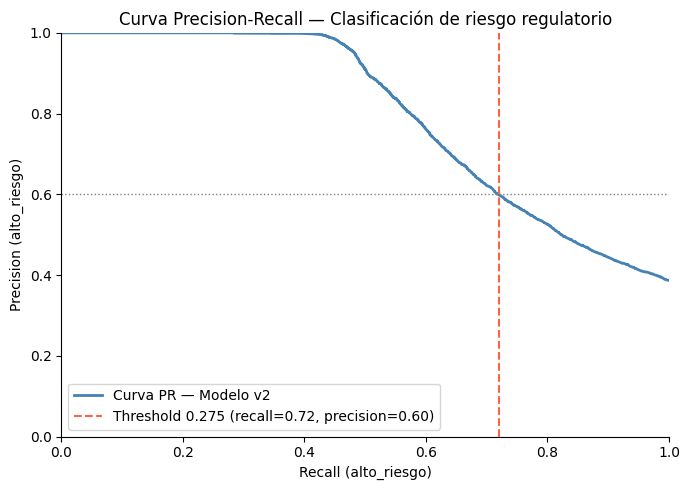

In [40]:


fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(recalls, precisions, color='steelblue', lw=2, label='Curva PR — Modelo v2')
ax.axvline(x=0.72, color='tomato', linestyle='--', lw=1.5, label=f'Threshold 0.275 (recall=0.72, precision=0.60)')
ax.axhline(y=0.60, color='gray', linestyle=':', lw=1)

ax.set_xlabel('Recall (alto_riesgo)')
ax.set_ylabel('Precision (alto_riesgo)')
ax.set_title('Curva Precision-Recall — Clasificación de riesgo regulatorio')
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150)
plt.show()

### Resultados S3: Modelado

Se entrenó un Random Forest con split temporal estricto (train 2021–2023 / test 2024–2026)
sobre 109.718 registros donde `TASA_FAVOR` es calculable (25.2% del dataset).

**Hallazgo crítico: modelo v1:** ROC-AUC 0.9989, resultado inválido.
`N1` y `N2` concentraban el 70% de la importancia y reconstruyen el denominador
de `TASA_FAVOR`. El modelo aprendió el ratio, no el riesgo.

**Modelo v2 (limpio):** ROC-AUC 0.79. Threshold ajustado a 0.275 (precision ≥ 0.60):

| Métrica               | Valor  |
| --------------------- | ------ |
| Recall alto_riesgo    | 0.72   |
| Precision alto_riesgo | 0.60   |
| ROC-AUC               | 0.7937 |

**Por qué estas métricas:** un falso negativo (entidad de alto riesgo no detectada)
tiene mayor costo regulatorio que un falso positivo (falsa alarma investigable).
El recall es la métrica prioritaria. La precision actúa como piso operativo:
por debajo de 0.60 el volumen de falsas alarmas hace inviable la supervisión.

**Variable más importante:** `QUEJAS_RECIBIDAS` (37%) — volumen de quejas entrantes
es el predictor dominante del riesgo, seguido de `CODIGO_MOTIVO` (17%) y
`CODIGO_PRODUCTO` (11%). Las variables de backlog y tramitación aportan señal secundaria.

**Acción concreta:** entidades clasificadas como alto riesgo en dos trimestres consecutivos
deberían activar revisión supervisora prioritaria en la SFC, priorizando por motivo
y producto dominante en sus quejas.

**Limitaciones:**

1. Cobertura del 25.2%: El modelo solo aplica donde ambas columnas de favor están reportadas.
2. Cambio de granularidad en 2023: Train y test pueden tener distribuciones de features
   estructuralmente distintas, lo que puede subestimar el error real de generalización.
3. Proxy imperfecto: `TASA_FAVOR` reconstruida no equivale a la variable original
   del enunciado; el umbral 0.70 es una decisión analítica, no un estándar regulatorio.
